## Exploring New Emergence of Varianty
**Author:** Karen Guzman

**Description:** Exploring different values of susceptible, infected, and recovered individuals with two variants. We introduce the new variant's transmission rate, beta2.


**Date:** 6/19/2026

In [26]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../models')
#imports
import numpy as np
import matplotlib.pyplot as plt
import new_emergence as ne

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
params = [0.6, 0.9, 0.45, 0.45] #beta1, beta2, gamma1, gamma2
y0 = [990, 10, 0, 0, 0] # 990 susceptible, 10 infected with strain 1, 0 infected with strain 2, 0 recovered from strain 1, 0 recovered from strain 2
t, y = ne.simulate_emergence(params,y0, t_emerge=50)

Peak of Strain 1: 41.773659282840846 at time 16.96969696969697
Peak of Strain 2: 1.6729013245514486 at time 89.31572629051621
Total infected with Strain 1: 473.1649163487143
Total infected with Strain 2: 66.58733979672412


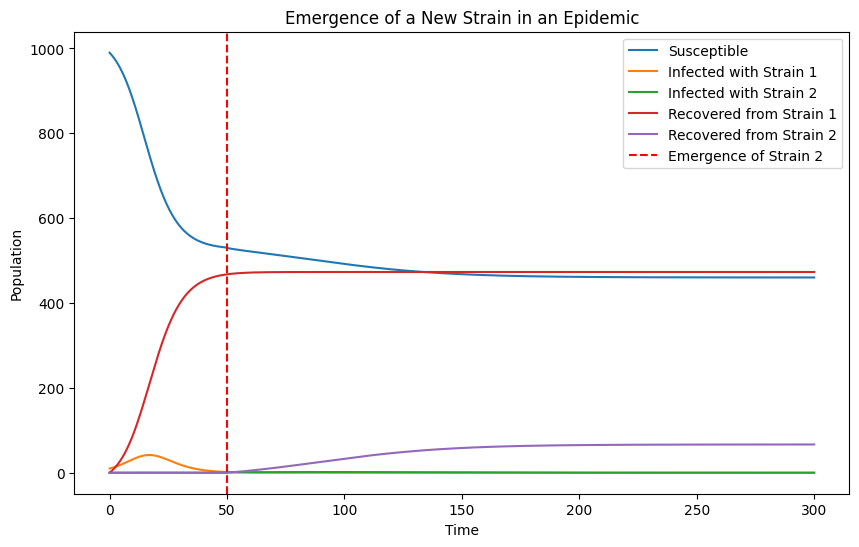

In [28]:
ne.plot_emergence(t, y)

**Exploring difference scenarios**

Scenario 1 - Emergence, replacement, and takeoever by variant 2

Peak of Strain 1: 74.5835458453427 at time 6.6132264529058125
Peak of Strain 2: 187.47353158609062 at time 174.04809619238478
Total infected with Strain 1: 527.9469005771338
Total infected with Strain 2: 504.75116289404457


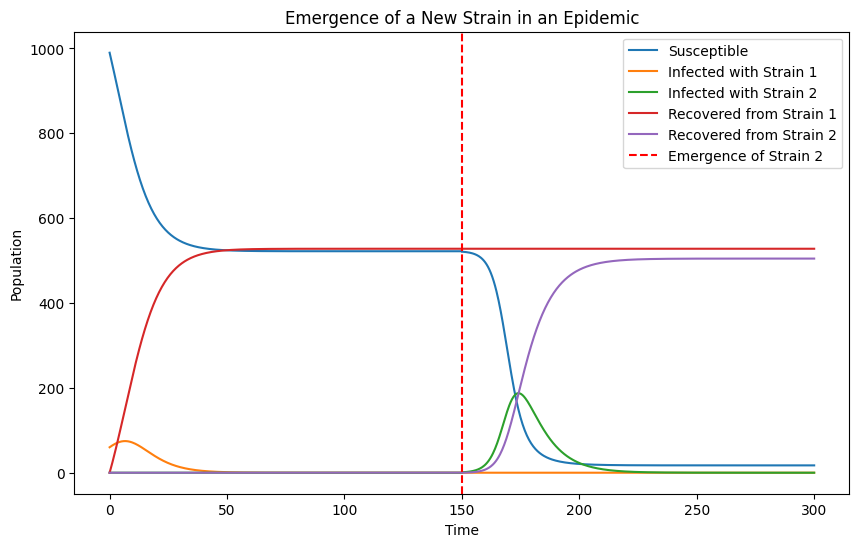

In [29]:
#where variant 2 emerges and takes over
params = [0.42, 0.85, 0.33, 0.12] #beta1, beta2, gamma1, gamma2
y0 = [990, 60, 0, 0, 0] # 990 susceptible, 60 infected with strain 1, 0 infected with strain 2, 0 recovered from strain 1, 0 recovered from strain 2
t, y = ne.simulate_emergence(params, y0, t_emerge=150)

ne.plot_emergence(t, y)

Variant 2 emerges after the first has burned out. Variant 1 $(R_0 = 1.27)$ produces an early wave, infecting about 528 of the population. Variant 2 emerged t = 150 at a more transmissible rate $(R_0 = 7.08)$. It infects about 505 people in total. Since each person catches at most one variant, the two strains end up infecting different halves of the population, leaving only about 17 people who had never been infected by either. 

Scenario 2 - Variant 1 and 2 circulating at the same time

Peak of Strain 1: 108.60834782145348 at time 3.384615384615385
Peak of Strain 2: 155.00180964836042 at time 45.80921757770632
Total infected with Strain 1: 574.9571718943256
Total infected with Strain 2: 452.7746002392804


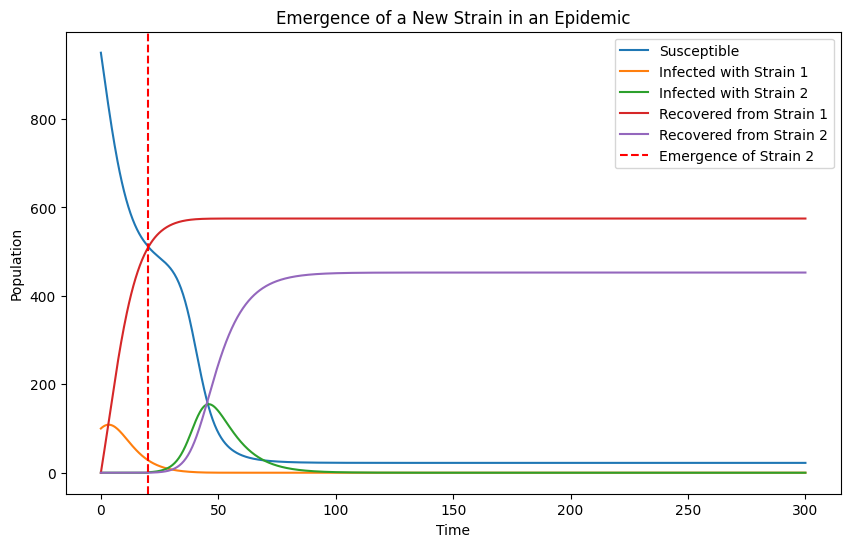

In [ ]:
#same params as scenario 1, increasing the initial number of infected with strain 1 to 100
params = [0.42, 0.85, 0.33, 0.12] #beta1, beta2, gamma1, gamma2
y0 = [950, 100, 0, 0, 0] # 990 susceptible, 100 infected with strain 1, 0 infected with strain 2, 0 recovered from strain 1, 0 recovered from strain 2
t, y = ne.simulate_emergence(params, y0, t_emerge=20)

ne.plot_emergence(t, y)

Variant 2 emerges at t = 20. In this scenario, the starting infected population with variant 1 is 100 people. Because both variants are competing for the same susceptible pool, variant 1 ends up infecting more people (592 vs 475), even though variant 2 has a higher transmission rate ($R_0$ = 7.08 vs 1.27). In total, about 1028 people are infected with either strain and 12 are never infected. 

Scenario 3 - Variant 2 emerges and fails to take over

Peak of Strain 1: 301.32831578967085 at time 5.735849056603773
Peak of Strain 2: 1.0 at time 80.0
Total infected with Strain 1: 970.3828036372632
Total infected with Strain 2: 2.1123411352743044


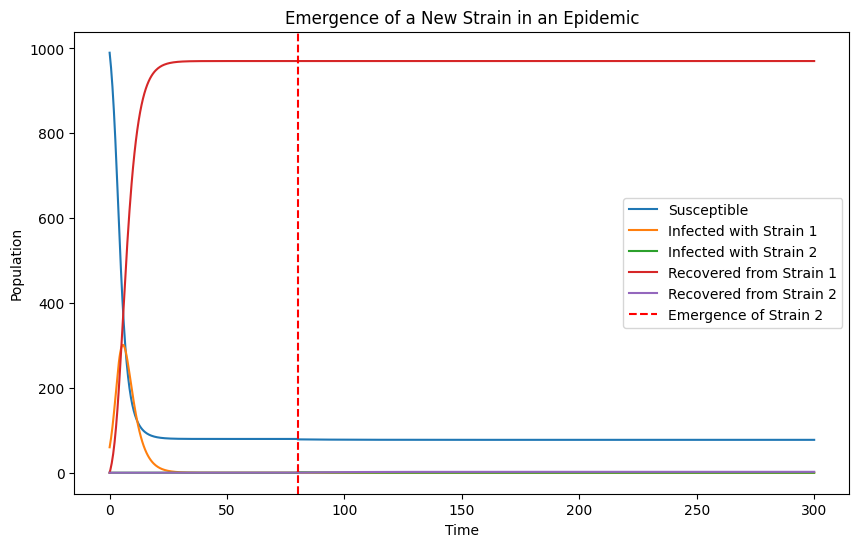

In [ ]:
#variant 2 emerges but does not take over
params = [.9, 0.85, 0.33, 0.12] #beta1, beta2, gamma1, gamma2
y0 = [990, 60, 0, 0, 0] # 990 susceptible, 60 infected with strain 1, 0 infected with strain 2, 0 recovered from strain 1, 0 recovered from strain 2
t, y = ne.simulate_emergence(params, y0, t_emerge=80)

ne.plot_emergence(t, y)

Here, $R_0 =2.73$, which is up from 1.27. Variant 1 infects almost everyone and variant 2 fails to establish. This is because variant 2's reproductive number is less than 1 $(R0₂ × S/N = 7.08 × 56/1,050 = 0.38)$